<a href="https://colab.research.google.com/github/AntoninaStadnik/ITStep-AI/blob/superwised_learning/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D0%BE%D0%B1%D1%80%D0%BE%D0%B1%D0%BA%D0%B0_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%BF%D1%80%D0%B5%D0%BF%D1%80%D0%BE%D1%86%D0%B5%D1%81%D0%BE%D1%80_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D0%BE_17.09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor

In [73]:
df = pd.read_csv("https://raw.githubusercontent.com/HalyshAnton/IT-Step-Pyton-AI/main/module3/data/Used%20Car%20Dataset.csv", index_col="Unnamed: 0")
#df.drop(columns=['car_name', 'registration_year', 'ownsership', 'transmission'], inplace=True)

Дані про ціни вживаних автомобілів у Індії
* car_name - назва авто у форматі 'рік компанія основна назва'
* registration_year - місяць та рік реєстрації
* ownsership - кількість власників у форматі 'Second owner'
* transmission - тип коробки передач
* insurance_validity - тип страховки
* fuel_type - вид палива
* seats - кількість сидінь
* kms_driven - пробіг
* manufacturing_year - рік виробництва, має тип object, потрібно застосувати astype(int)
* mileage(kmpl) - скільки кілометрів проїде за літр палива
* engine(cc) - об'єм двигуна у мл
* max_power(bhp) - потужність у кінських силах
* torque(Nm) - крутний момент двигуна
* price(in lakhs) - ціна у сто тисяч рупій

[Повний аналіз даних](https://www.kaggle.com/code/abdelrasoul/used-cars-prices-prediction)

In [74]:
df.head()

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm),price(in lakhs)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0,63.75
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0,8.99
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0,23.75
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0,13.56
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0,24.00


# Завдання 1
Виведіть інформацію про таблицю(кількість рядків та стовпчиків та типи даних). Також виведіть кількість пропущених значень по стовпчиках

In [75]:
df.shape

(1553, 14)

In [76]:
df.isna().sum()

,0
car_name,0
registration_year,0
insurance_validity,0
fuel_type,0
seats,0
kms_driven,0
ownsership,0
transmission,0
manufacturing_year,0
mileage(kmpl),3


# Завдання 2
Виведіть гістограми для всіх числових стовпчиків

In [77]:
df.dtypes

,0
car_name,object
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64


Text(0.5, 0, 'amount')

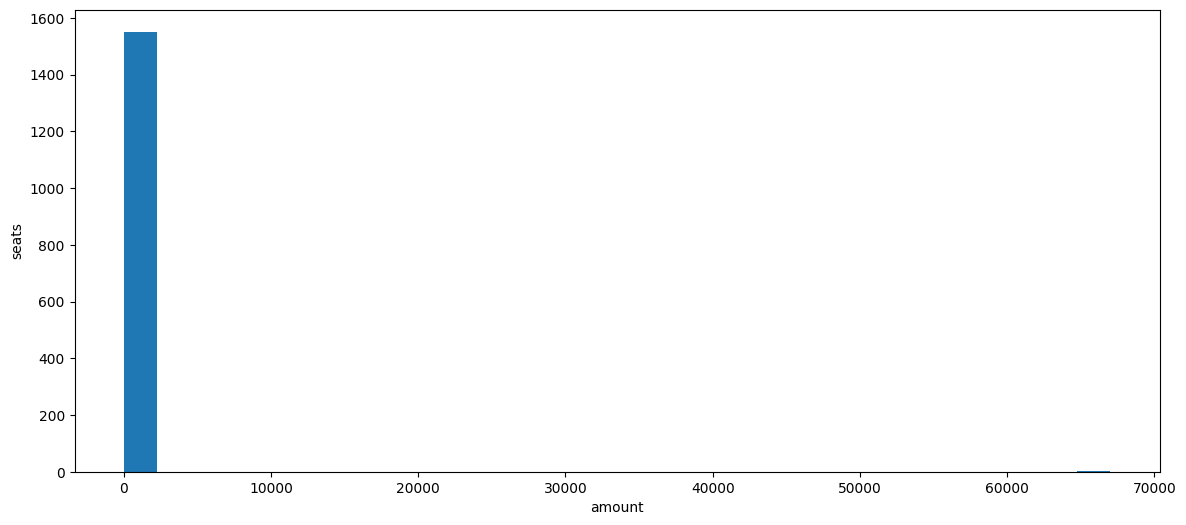

In [78]:
ax = df['seats'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('seats')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

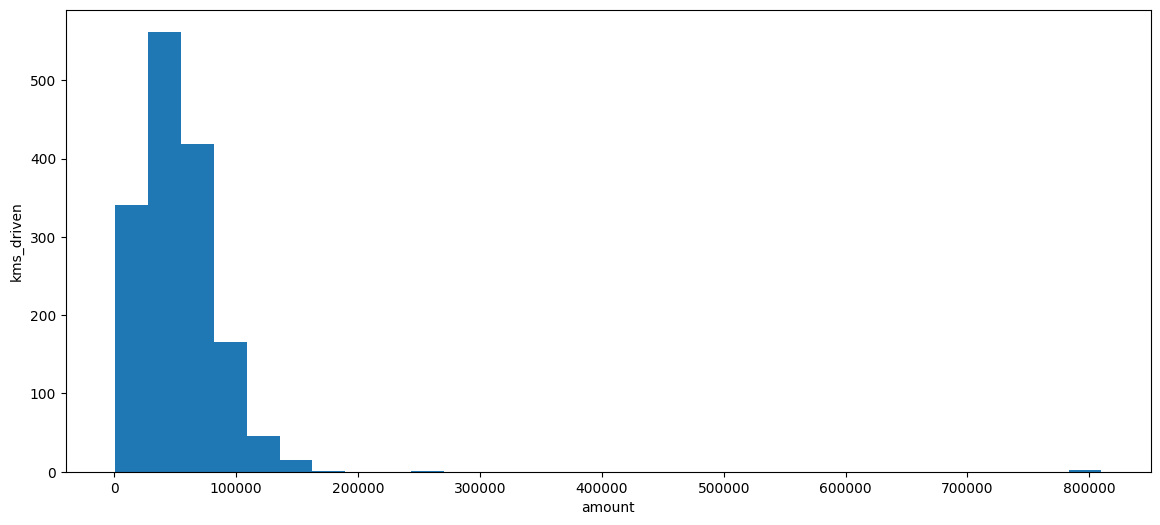

In [79]:
ax = df['kms_driven'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('kms_driven')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

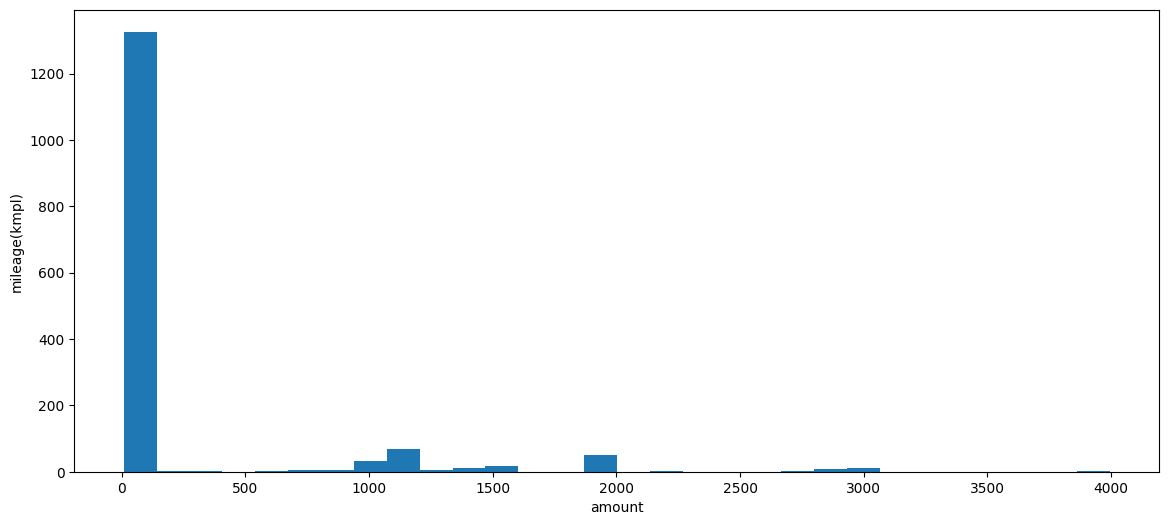

In [80]:
ax = df['mileage(kmpl)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('mileage(kmpl)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

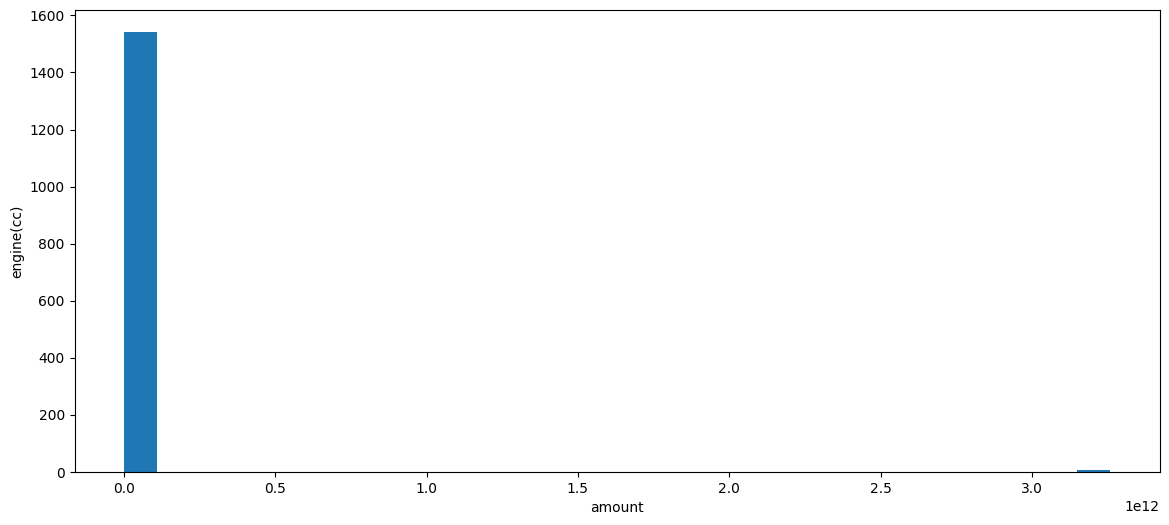

In [81]:
ax = df['engine(cc)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('engine(cc)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

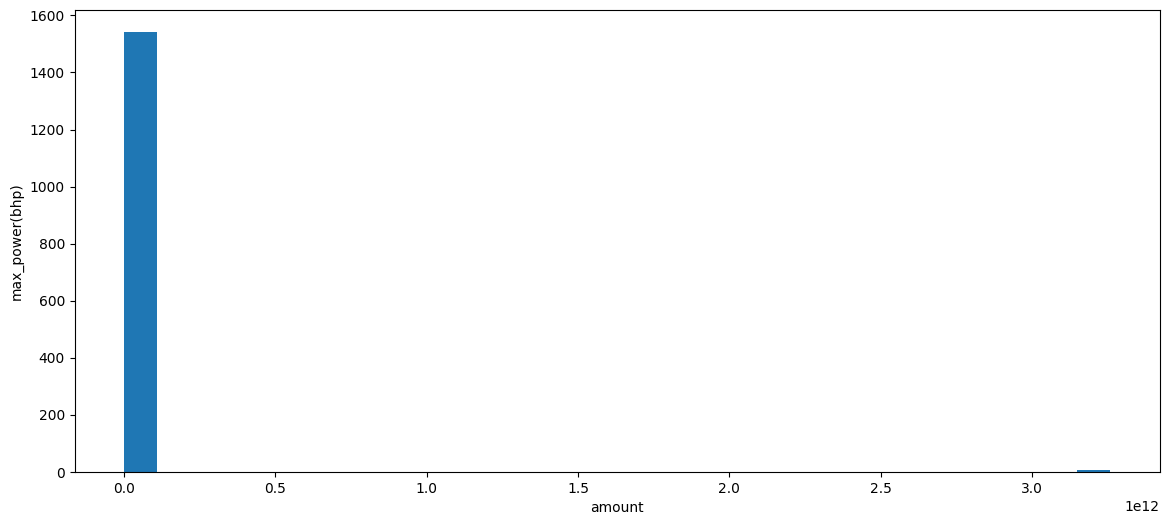

In [82]:
ax = df['max_power(bhp)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('max_power(bhp)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

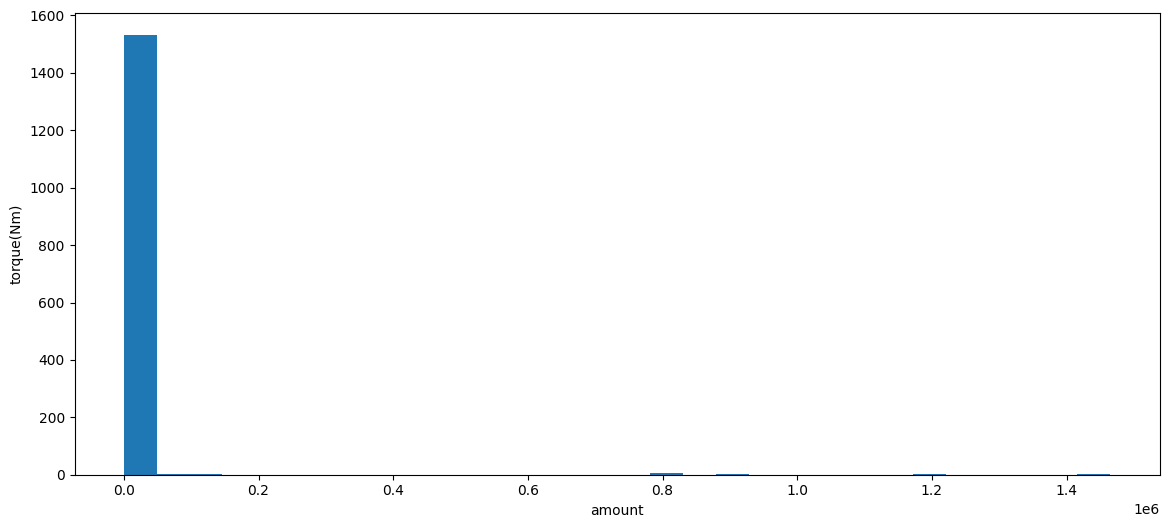

In [83]:
ax = df['torque(Nm)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('torque(Nm)')
ax.set_xlabel('amount')

Text(0.5, 0, 'amount')

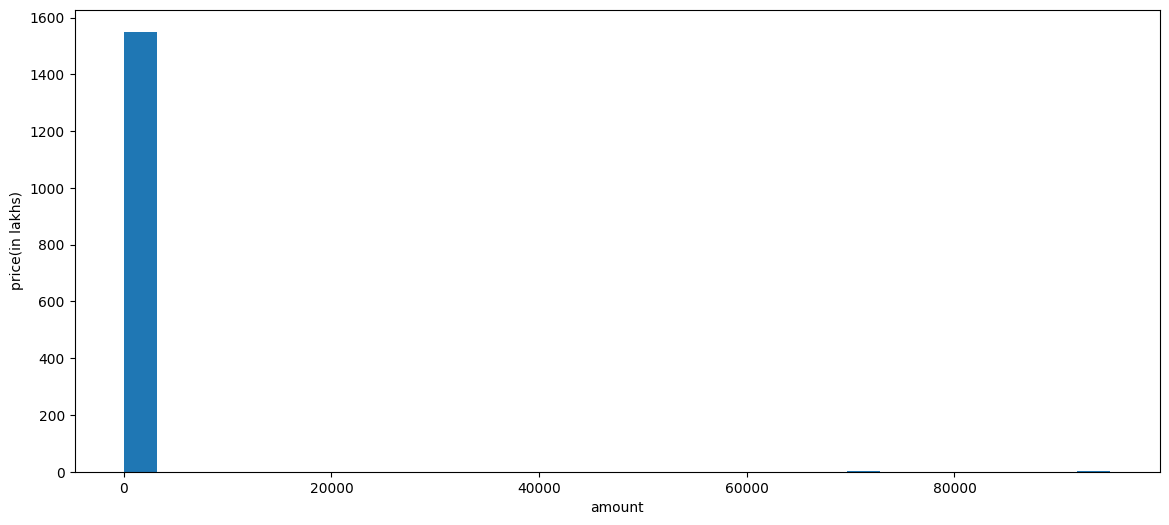

In [84]:
ax = df['price(in lakhs)'].plot(kind='hist',    # тип діаграми hist
                             bins=30,        # кількість стовпчиків
                             figsize=(14,6)  # розмір зображення(в дюймах)
                             )


ax.set_ylabel('price(in lakhs)')
ax.set_xlabel('amount')

# Завдання 3
Виведіть ящик з вусами для всіх числових стовпчиків. Де потрібно очистіть викиди

<Axes: >

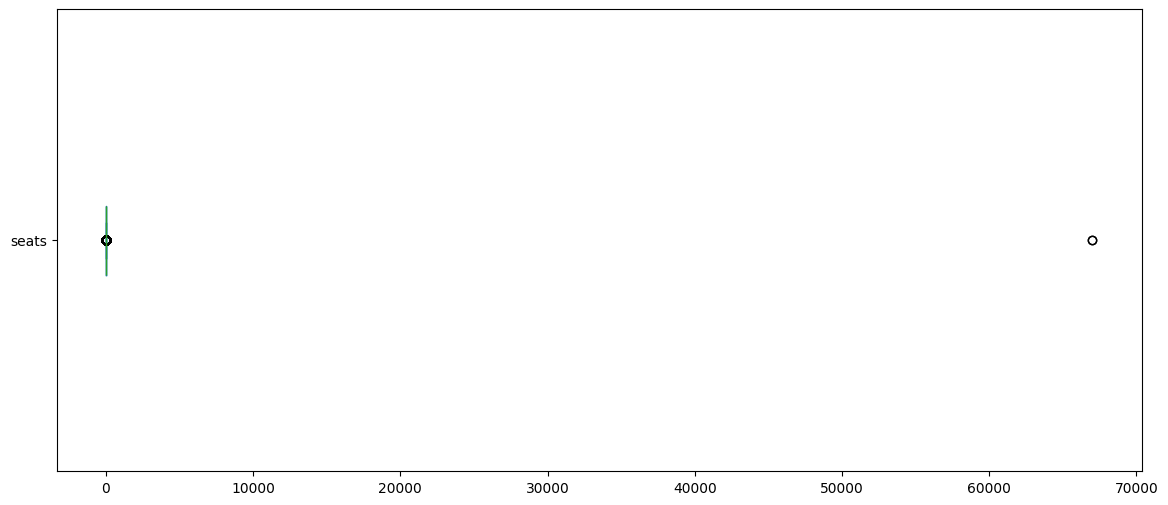

In [85]:
df['seats'].plot(kind='box', vert=False, figsize=(14,6))

In [86]:
mask = df['seats'] < 1000
mask.sum()

np.int64(1551)

In [87]:
df = df[mask]

In [88]:
mask = df['kms_driven'] < 175000
mask.sum()

np.int64(1547)

In [89]:
df = df[mask]

<Axes: >

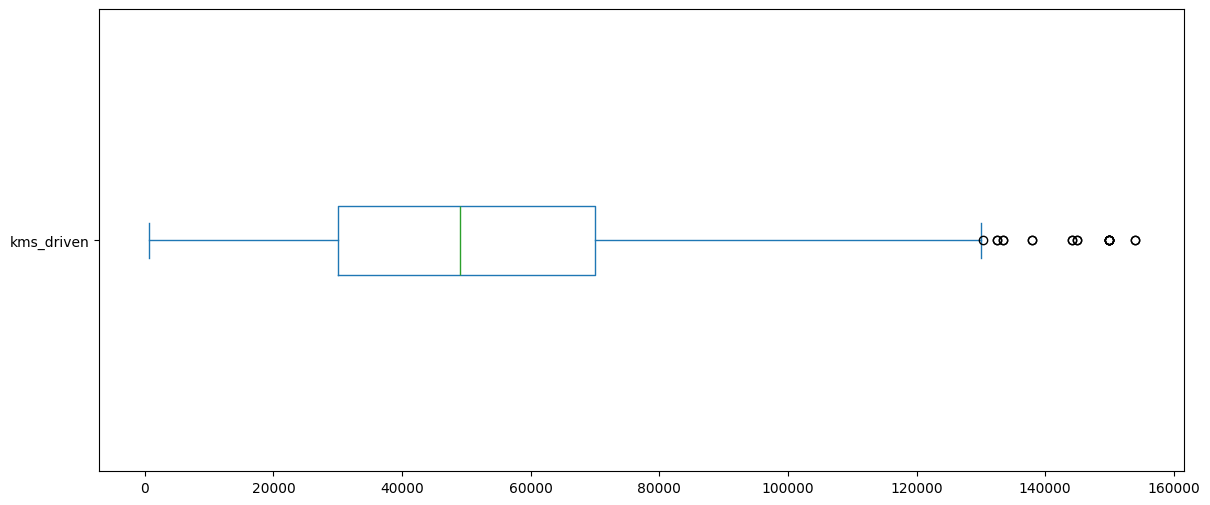

In [90]:
df['kms_driven'].plot(kind='box', vert=False, figsize=(14,6))

In [91]:
mask = df['mileage(kmpl)'] < 100
mask.sum()

np.int64(1322)

In [92]:
df = df[mask]

<Axes: >

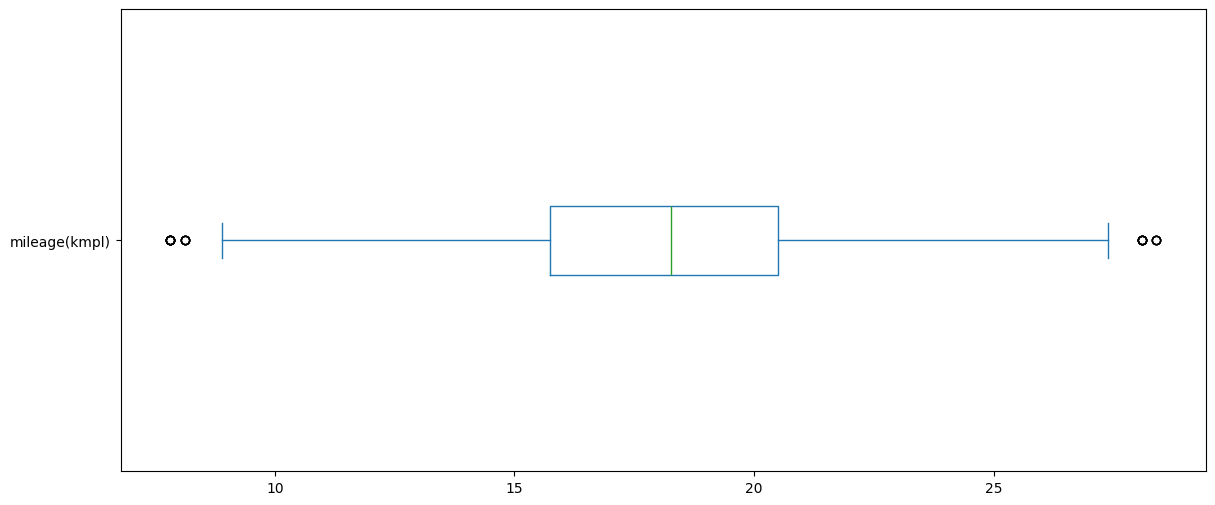

In [93]:
df['mileage(kmpl)'].plot(kind='box', vert=False, figsize=(14,6))

In [94]:
df.dtypes

,0
car_name,object
registration_year,object
insurance_validity,object
fuel_type,object
seats,int64
kms_driven,int64
ownsership,object
transmission,object
manufacturing_year,object
mileage(kmpl),float64


In [95]:
mask = df['engine(cc)'] < 4000
mask.sum()

np.int64(1317)

In [96]:
df = df[mask]

<Axes: >

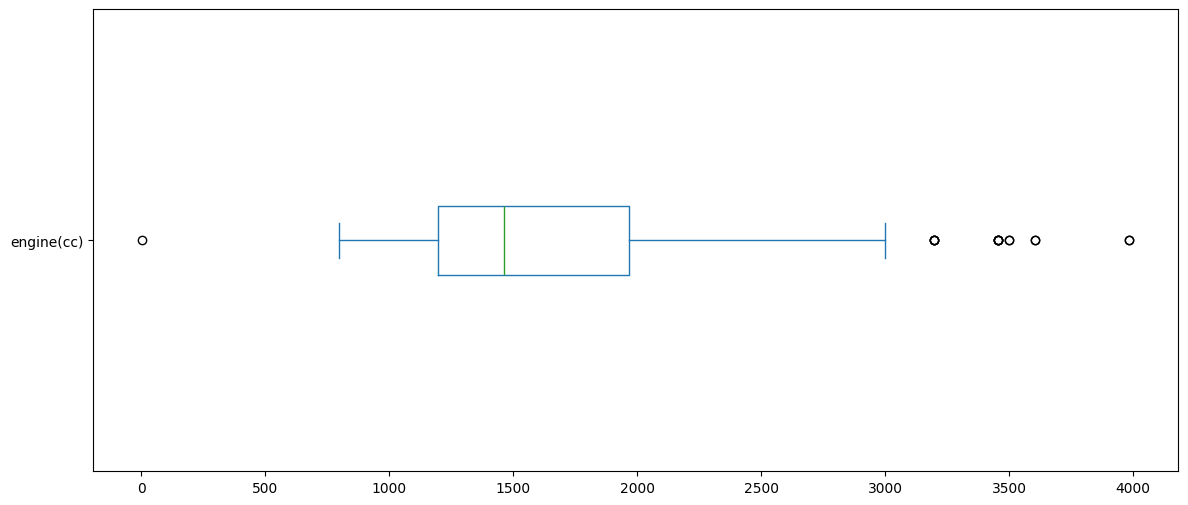

In [97]:
df['engine(cc)'].plot(kind='box', vert=False, figsize=(14,6))

<Axes: >

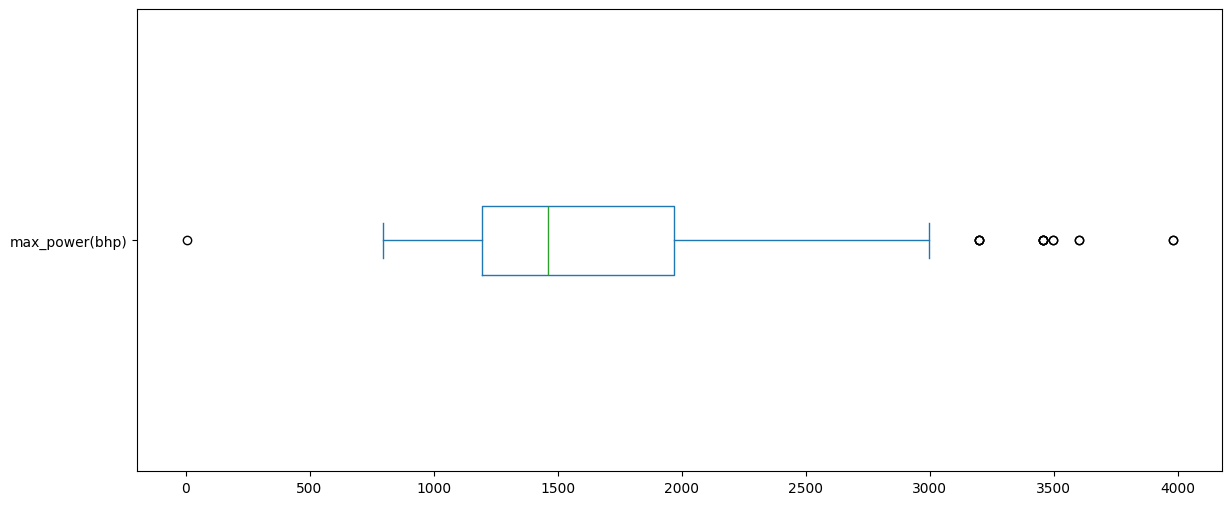

In [98]:
df['max_power(bhp)'].plot(kind='box', vert=False, figsize=(14,6))

In [99]:
mask = df['torque(Nm)'] < 40000
mask.sum()

np.int64(1302)

In [100]:
df = df[mask]

<Axes: >

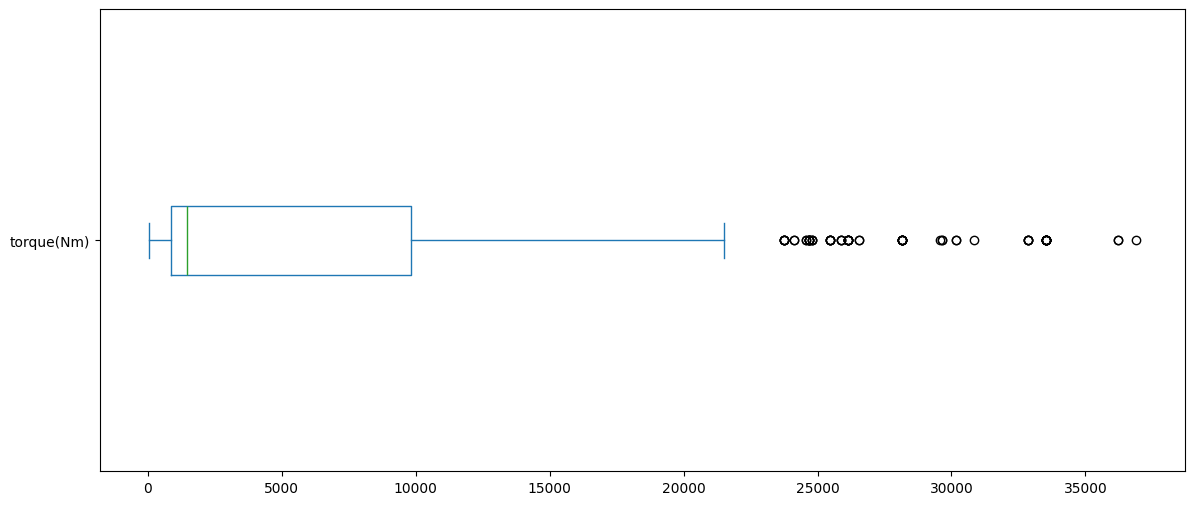

In [101]:
df['torque(Nm)'].plot(kind='box', vert=False, figsize=(14,6))

In [102]:
mask = df['price(in lakhs)'] < 20000
mask.sum()

np.int64(1301)

In [103]:
df = df[mask]

<Axes: >

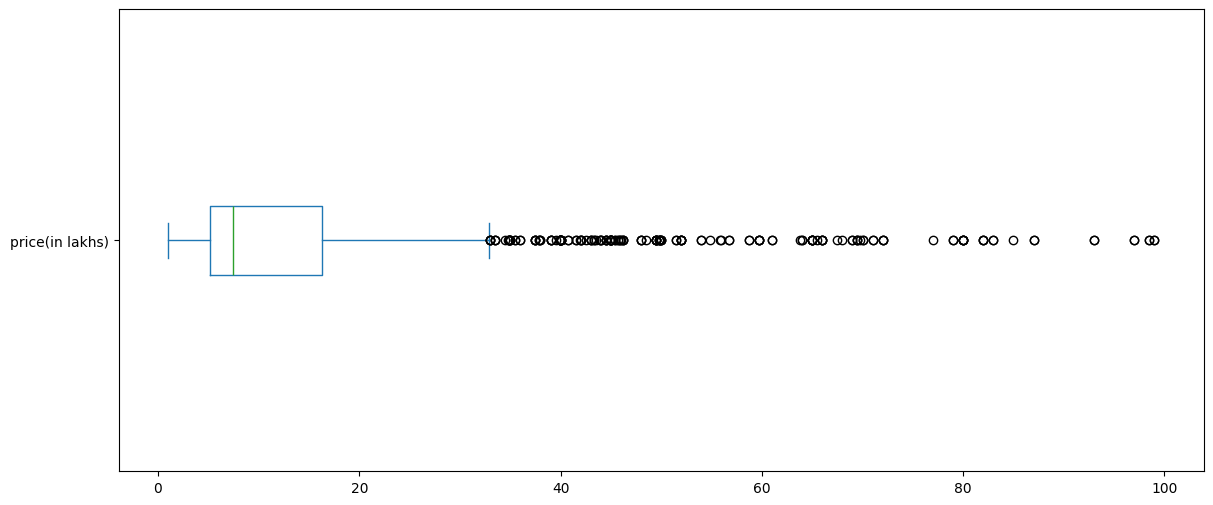

In [104]:
df['price(in lakhs)'].plot(kind='box', vert=False, figsize=(14,6))

#Завдання 1
Очистіть дані від викидів, розділіть на тренувальну та тестову чатини

In [105]:
y = df['price(in lakhs)']
x = df.drop(columns = 'price(in lakhs)')

x

,car_name,registration_year,insurance_validity,fuel_type,seats,kms_driven,ownsership,transmission,manufacturing_year,mileage(kmpl),engine(cc),max_power(bhp),torque(Nm)
0,2017 Mercedes-Benz S-Class S400,Jul-17,Comprehensive,Petrol,5,56000,First Owner,Automatic,2017,7.81,2996.0,2996.0,333.0
1,2020 Nissan Magnite Turbo CVT XV Premium Opt BSVI,Jan-21,Comprehensive,Petrol,5,30615,First Owner,Automatic,2020,17.40,999.0,999.0,9863.0
2,2018 BMW X1 sDrive 20d xLine,Sep-18,Comprehensive,Diesel,5,24000,First Owner,Automatic,2018,20.68,1995.0,1995.0,188.0
3,2019 Kia Seltos GTX Plus,Dec-19,Comprehensive,Petrol,5,18378,First Owner,Manual,2019,16.50,1353.0,1353.0,13808.0
4,2019 Skoda Superb LK 1.8 TSI AT,Aug-19,Comprehensive,Petrol,5,44900,First Owner,Automatic,2019,14.67,1798.0,1798.0,17746.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1546,2018 Honda Jazz V CVT,May-18,Comprehensive,Petrol,5,19446,First Owner,Automatic,2018,18.20,1199.0,1199.0,887.0
1547,2022 Maruti Ertiga VXI CNG,May-22,Third Party insurance,CNG,7,26500,First Owner,Manual,2022,26.11,1462.0,1462.0,8663.0
1550,2017 Honda WR-V i-VTEC S,Jun-17,Comprehensive,Petrol,5,49000,First Owner,Manual,2017,17.50,1199.0,1199.0,887.0
1551,2018 Volkswagen Polo 1.0 MPI Comfortline,May-18,Comprehensive,Petrol,5,40000,Second Owner,Manual,2018,18.78,999.0,999.0,75.0


In [106]:
X = df.drop("price(in lakhs)", axis=1) #розподілення на х та у - для розподілення данних на навчання і верифікацію
y = df["price(in lakhs)"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1040, 13)
(261, 13)


In [107]:
X_train.shape

(1040, 13)

#Завдання 2
Створіть Pipeline для обробки даних

In [108]:
# 1. manufacturing_year має бути числовим
df["manufacturing_year"] = pd.to_numeric(
    df["manufacturing_year"],
    errors="coerce"
)


# 2. Цільова змінна
X = df.drop("price(in lakhs)", axis=1)
y = df["price(in lakhs)"]


# 3. Видаляємо car_name та registration_year
# якщо вони не потрібні для моделі
X = X.drop(["car_name", "registration_year"], axis=1)


# 4. Визначаємо числові та категоріальні колонки
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns


# 5. Pipeline для числових даних
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# 6. Pipeline для категоріальних даних
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


# 7. Об'єднуємо обробку
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)


# 8. Створюємо повний Pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])


# 9. Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [109]:
# 9. Розділення на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [110]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 Index(['seats', 'kms_driven', 'manufacturing_year', 'mileage(kmpl)',
       'engine(cc)', 'max_power(bhp)', 'torque(Nm)'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 Index(['insurance_validity', 'fuel_type', 'ownsership', 'transmission'], dtype='object'))])

#Завдання 3
Створіть остаточну модель та натренуйте її

In [111]:
final_price_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),  # Трансформація: стрінги -> інти
    ('tree_regressor', DecisionTreeRegressor(
        max_depth=4,        # Обмеження глибини, щоб дерево не перенавчалося і краще прогнозувало ціну
        min_samples_leaf=5,  # Мінімальна кількість об'єктів у листку для стабільності прогнозу
        random_state=42      # Фіксація випадковості для відтворюваності результатів
    ))
])

In [112]:
final_price_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['seats', 'kms_driven', 'manufacturing_year', 'mileage(kmpl)',
       'engine(cc)', 'max_power(bhp)', 'torque(Nm)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['insurance_validity', 'fuel_type', 'ownsership', 'transmission'], dtype='object'))])),
                ('tree_regressor',
                 DecisionTreeRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=42))])

In [113]:
final_price_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['seats', 'kms_driven', 'manufacturing_year', 'mileage(kmpl)',
       'engine(cc)', 'max_power(bhp)', 'torque(Nm)'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['insurance_validity', 'fuel_type', 'ownsership', 'transmission'], dtype='object'))])),
                ('tree_regressor',
                 DecisionTreeRegressor(max_depth=4, min_samples_leaf=5,
                                       random_state=42))])

In [114]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from google.colab import files  # Модуль для скачування файлів у Colab

# 1. Налаштовуємо полотно та повністю прибираємо графічні рамки
fig, ax = plt.subplots(figsize=(25, 15), dpi=300)
ax.axis('off')

# 2. Малюємо виключно структуру дерева
plot_tree(
    final_price_pipeline.named_steps['tree_regressor'],
    feature_names=final_price_pipeline.named_steps['preprocessor'].get_feature_names_out(),
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax
)

# 3. Зберігаємо у файл без зайвих відступів по краях
output_filename = "decision_tree.pdf"
plt.savefig(output_filename, format='pdf', bbox_inches='tight', pad_inches=0)
plt.close()

# 4. Автоматично скачуємо файл через браузер із Google Colab
files.download(output_filename)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [118]:
pred_price = final_price_pipeline.predict(X_test)


In [120]:
results_df = pd.DataFrame({
    'Реальна ціна': np.array(y_test).flatten(),
    'Прогноз моделі': np.array(pred_price).flatten()
})
results_df

,Реальна ціна,Прогноз моделі
0,46.21,58.610909
1,1.50,78.095238
2,3.95,7.984394
3,7.80,11.533696
4,43.50,58.610909
...,...,...
256,65.00,49.119400
257,3.95,7.984394
258,49.50,32.526190
259,7.14,7.523759
